# LASSO Tracking Portfolio for S&P 500

Cleaned version aligned with the autoencoder notebook: streamlined data prep, comparable evaluation metrics, and only the core plots needed for replication analysis.

In [ ]:
!pip -q install pandas numpy scikit-learn matplotlib tqdm

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print('Drive mount skipped:', e)

data_path = Path('/content/drive/MyDrive/Mega')
print('Data dir exists:', data_path.exists())
print('Example files:', [p.name for p in list(data_path.glob('*.csv'))[:5]])

Mounted at /content/drive
Data dir exists: True
Example files: ['sp500_tickers_cache.csv', 'ABNB.csv', 'APP.csv', 'CARR.csv', 'CEG.csv']


In [ ]:
def load_returns_panel(data_dir: Path, benchmark_name='^GSPC.csv', min_coverage=0.80):
    if not data_dir.exists():
        raise FileNotFoundError(f'Data directory does not exist: {data_dir}')

    bench_path = data_dir / benchmark_name
    if not bench_path.exists():
        raise FileNotFoundError(f'Benchmark file not found: {bench_path}')

    bench = pd.read_csv(bench_path)
    bench.columns = bench.columns.str.strip()
    if 'Date' not in bench.columns or 'Close' not in bench.columns:
        raise ValueError(f'{benchmark_name} must contain Date and Close columns.')

    bench['Date'] = pd.to_datetime(bench['Date'], errors='coerce')
    bench = bench.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset='Date', keep='last')
    bench['Return'] = bench['Close'].pct_change()
    bench = bench[['Date', 'Return']].dropna().set_index('Date').rename(columns={'Return': 'benchmark_return'})

    returns = {}
    for file in sorted(data_dir.glob('*.csv')):
        if file.name == benchmark_name:
            continue
        try:
            df = pd.read_csv(file)
            df.columns = df.columns.str.strip()
            if 'Date' not in df.columns or 'Close' not in df.columns:
                continue
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            df = df.dropna(subset=['Date']).sort_values('Date').drop_duplicates(subset='Date', keep='last')
            df['Return'] = df['Close'].pct_change()
            series = df.set_index('Date')['Return'].rename(file.stem)
            returns[file.stem] = series
        except Exception:
            continue

    stock_returns = pd.DataFrame(returns).sort_index()
    aligned = stock_returns.join(bench, how='inner').dropna(subset=['benchmark_return'])

    if aligned.empty:
        raise RuntimeError('No overlapping dates found between stock files and benchmark.')

    coverage = aligned.drop(columns=['benchmark_return']).notna().mean().sort_values(ascending=False)
    eligible = coverage[coverage >= min_coverage].index.tolist()
    aligned = aligned[eligible + ['benchmark_return']].dropna(axis=0, how='any')

    X = aligned.drop(columns=['benchmark_return'])
    y = aligned['benchmark_return']

    print('Aligned return matrix:', X.shape)
    print('Date range:', X.index.min().date(), '->', X.index.max().date())
    print('Eligible tickers:', X.shape[1])
    return X, y


X_all, y_all = load_returns_panel(data_path)

Aligned return matrix: (1181, 561)
Date range: 2021-02-11 -> 2025-11-28
Eligible tickers: 561


In [ ]:
# Time-based split, similar in spirit to the autoencoder notebook.
dates = X_all.index.sort_values()
n = len(dates)
fit_end_idx = max(int(n * 0.70), 1)
sel_end_idx = max(int(n * 0.85), fit_end_idx + 1)

FIT_END = dates[fit_end_idx - 1]
SEL_START = dates[fit_end_idx]
SEL_END = dates[sel_end_idx - 1]
HOLD_START = dates[sel_end_idx]

fit_mask = X_all.index <= FIT_END
sel_mask = (X_all.index >= SEL_START) & (X_all.index <= SEL_END)
hold_mask = X_all.index >= HOLD_START

X_fit_raw = X_all.loc[fit_mask].copy()
y_fit = y_all.loc[fit_mask].copy()

X_sel_raw = X_all.loc[sel_mask].copy()
y_sel = y_all.loc[sel_mask].copy()

X_hold_raw = X_all.loc[hold_mask].copy()
y_hold = y_all.loc[hold_mask].copy()

usable_cols = X_fit_raw.columns[X_fit_raw.notna().any(axis=0)].tolist()
X_fit_raw = X_fit_raw[usable_cols]
X_sel_raw = X_sel_raw[usable_cols]
X_hold_raw = X_hold_raw[usable_cols]

print('Fit:', X_fit_raw.shape, 'Selection:', X_sel_raw.shape, 'Holdout:', X_hold_raw.shape)
print('Fit end:', FIT_END.date(), '| Selection:', SEL_START.date(), '->', SEL_END.date(), '| Holdout start:', HOLD_START.date())

Fit: (826, 561) Selection: (177, 561) Holdout: (178, 561)
Fit end: 2024-06-18 | Selection: 2024-06-20 -> 2025-03-10 | Holdout start: 2025-03-11


In [ ]:
scaler = StandardScaler()

X_fit_s = pd.DataFrame(scaler.fit_transform(X_fit_raw), index=X_fit_raw.index, columns=X_fit_raw.columns)
X_sel_s = pd.DataFrame(scaler.transform(X_sel_raw), index=X_sel_raw.index, columns=X_sel_raw.columns)
X_hold_s = pd.DataFrame(scaler.transform(X_hold_raw), index=X_hold_raw.index, columns=X_hold_raw.columns)

def annualized_tracking_error(active_returns: pd.Series) -> float:
    return float(active_returns.std(ddof=1) * np.sqrt(252))

def annualized_information_ratio(active_returns: pd.Series) -> float:
    std = active_returns.std(ddof=1)
    if std == 0 or np.isnan(std):
        return np.nan
    return float((active_returns.mean() / std) * np.sqrt(252))

def fit_lasso_portfolio(X_train: pd.DataFrame, y_train: pd.Series, alpha: float, max_iter: int = 20000):
    model = Lasso(alpha=alpha, max_iter=max_iter, random_state=42)
    model.fit(X_train.values, y_train.values)
    weights = pd.Series(model.coef_, index=X_train.columns)
    nnz = int((weights != 0).sum())
    if nnz == 0:
        return None, None

    abs_sum = weights.abs().sum()
    if abs_sum == 0:
        return None, None

    weights = weights / abs_sum
    return model, weights

def evaluate_portfolio(weights: pd.Series, X_part: pd.DataFrame, y_part: pd.Series):
    pred = X_part.dot(weights).reindex(y_part.index)
    active = (pred - y_part).dropna()
    return {
        'te_ann': annualized_tracking_error(active),
        'ir_ann': annualized_information_ratio(active),
        'pred': pred,
        'active': active,
    }

def evaluate_alpha(alpha: float):
    model, weights = fit_lasso_portfolio(X_fit_s, y_fit, alpha)
    if weights is None:
        return None

    fit_metrics = evaluate_portfolio(weights, X_fit_raw, y_fit)
    sel_metrics = evaluate_portfolio(weights, X_sel_raw, y_sel)
    hold_metrics = evaluate_portfolio(weights, X_hold_raw, y_hold)

    return {
        'alpha': alpha,
        'k': int((weights != 0).sum()),
        'fit_te_ann': fit_metrics['te_ann'],
        'sel_te_ann': sel_metrics['te_ann'],
        'hold_te_ann': hold_metrics['te_ann'],
        'fit_ir_ann': fit_metrics['ir_ann'],
        'sel_ir_ann': sel_metrics['ir_ann'],
        'hold_ir_ann': hold_metrics['ir_ann'],
        'weights': weights,
        'model': model,
    }

In [ ]:
alphas = np.logspace(-5, -1.5, 60)
rows = []

for alpha in tqdm(alphas, desc='Evaluating alpha'):
    out = evaluate_alpha(alpha)
    if out is None:
        continue
    rows.append({k: v for k, v in out.items() if k not in {'weights', 'model'}})

results_df = pd.DataFrame(rows)
if results_df.empty:
    raise RuntimeError('No valid LASSO models were produced.')

results_df = results_df.sort_values(['k', 'hold_te_ann', 'alpha']).reset_index(drop=True)
print('Results shape:', results_df.shape)
display(results_df.head())

Evaluating alpha:   0%|          | 0/60 [00:00<?, ?it/s]

Results shape: (50, 8)


,alpha,k,fit_te_ann,sel_te_ann,hold_te_ann,fit_ir_ann,sel_ir_ann,hold_ir_ann
0,0.008068,2,0.127831,0.262369,0.217221,1.033689,-0.577016,4.012955
1,0.006140,4,0.082003,0.112812,0.104766,0.882847,-0.593109,3.534357
2,0.007038,4,0.085775,0.137246,0.122874,0.959016,-0.610304,3.757373
3,0.005356,6,0.080627,0.099403,0.095046,0.803134,-0.596638,3.372673
4,0.004672,8,0.077853,0.085267,0.084648,0.798557,-0.658904,2.899113


In [ ]:
# One row per sparsity level: keep the alpha with the best holdout TE for each k
best_by_k = results_df.loc[results_df.groupby('k')['hold_te_ann'].idxmin()].copy()
best_by_k = best_by_k.sort_values('k').reset_index(drop=True)

pivot = best_by_k[['k', 'hold_te_ann', 'hold_ir_ann']].set_index('k')
display(pivot.round(4))

,hold_te_ann,hold_ir_ann
k,,
2,0.2172,4.0130
4,0.1048,3.5344
6,0.0950,3.3727
8,0.0846,2.8991
12,0.0741,2.5080
14,0.0670,2.1182
15,0.0623,1.8786
18,0.0597,1.6261
21,0.0569,1.4596


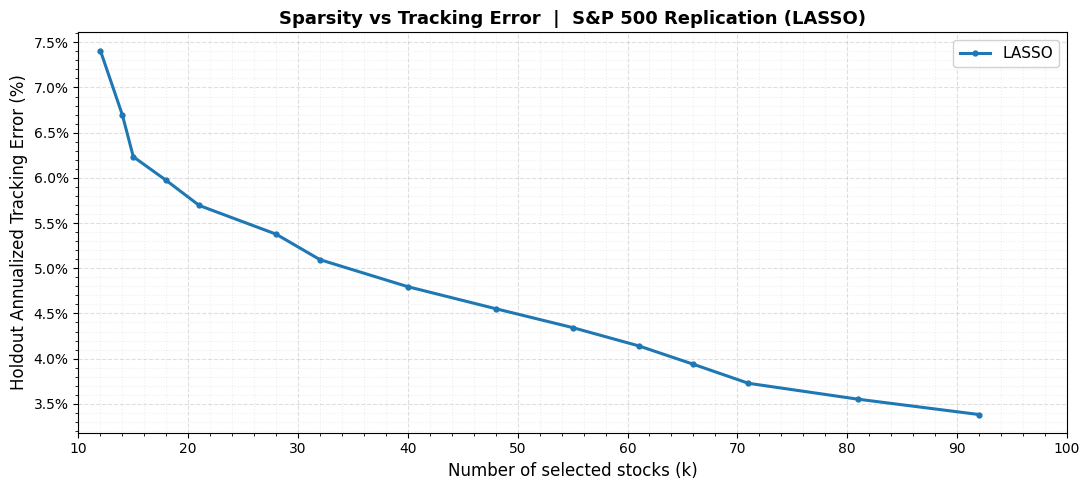

In [ ]:
WINDOW = 1
COLOR = '#1f77b4'
LABEL = 'LASSO'

sub = best_by_k[(best_by_k['k'] >= 10) & (best_by_k['k'] <= 100)].sort_values('k')
raw_k = sub['k'].values
raw_te = sub['hold_te_ann'].values
smoothed_te = pd.Series(raw_te).rolling(WINDOW, center=True, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(raw_k, raw_te * 100, color=COLOR, alpha=0.20, linewidth=1)
ax.plot(
    raw_k, smoothed_te * 100,
    color=COLOR, linewidth=2.2,
    marker='o', markersize=3.5,
    markevery=1,
    label=LABEL
)

ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Tracking Error (%)', fontsize=12)
ax.set_title('Sparsity vs Tracking Error  |  S&P 500 Replication (LASSO)',
             fontsize=13, fontweight='bold')

ax.set_xlim(10, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

plt.tight_layout()
plt.show()

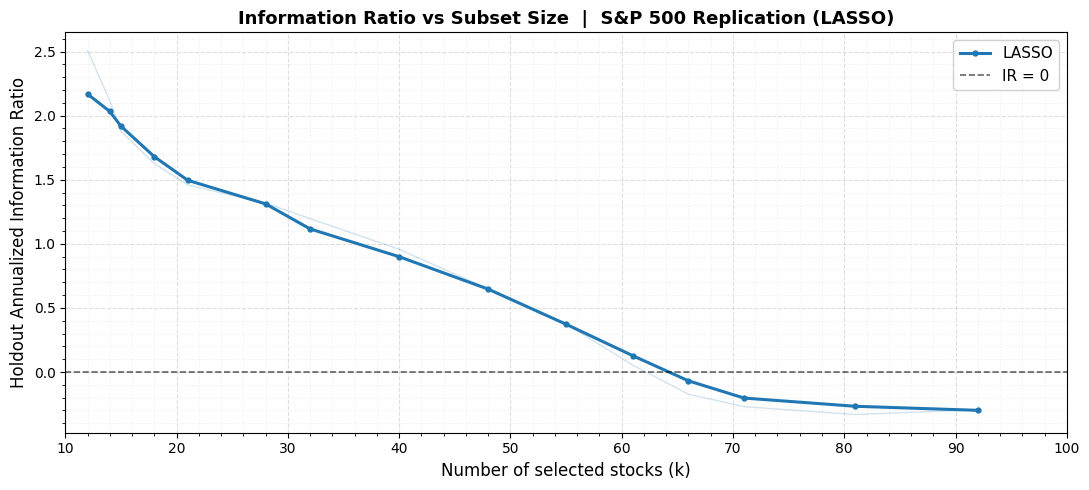

In [ ]:
WINDOW = 5
COLOR = '#1f77b4'
LABEL = 'LASSO'

sub = best_by_k[(best_by_k['k'] >= 10) & (best_by_k['k'] <= 100)].sort_values('k')
raw_k = sub['k'].values
raw_ir = sub['hold_ir_ann'].values
smoothed_ir = pd.Series(raw_ir).rolling(WINDOW, center=True, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(raw_k, raw_ir, color=COLOR, alpha=0.20, linewidth=1)
ax.plot(
    raw_k, smoothed_ir,
    color=COLOR, linewidth=2.2,
    marker='o', markersize=3.5,
    markevery=1,
    label=LABEL
)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label='IR = 0')

ax.set_xlabel('Number of selected stocks (k)', fontsize=12)
ax.set_ylabel('Holdout Annualized Information Ratio', fontsize=12)
ax.set_title('Information Ratio vs Subset Size  |  S&P 500 Replication (LASSO)',
             fontsize=13, fontweight='bold')

ax.set_xlim(10, 100)
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, which='major', linestyle='--', alpha=0.4)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

plt.tight_layout()
plt.show()

In [ ]:
# Pick the best candidate with k <= 50, matching the constraint used in the earlier notebook
best_candidates = results_df[results_df['k'] <= 50].copy()
if best_candidates.empty:
    best_candidates = results_df.copy()

best_row = best_candidates.loc[best_candidates['hold_te_ann'].idxmin()]
best_alpha = float(best_row['alpha'])
best_k = int(best_row['k'])

model, best_weights = fit_lasso_portfolio(X_fit_s, y_fit, best_alpha)
if best_weights is None:
    raise RuntimeError('Best model failed to produce weights.')

best_selection = pd.DataFrame({
    'ticker': best_weights.index,
    'weight': best_weights.values,
    'abs_weight': best_weights.abs().values,
}).sort_values('weight', ascending=False)

print(f'Best alpha: {best_alpha:.6f}')
print(f'Best k: {best_k}')
print(best_row[['alpha', 'k', 'fit_te_ann', 'sel_te_ann', 'hold_te_ann', 'fit_ir_ann', 'sel_ir_ann', 'hold_ir_ann']])

from IPython.display import display
display(best_selection.head(20))

Best alpha: 0.001366
Best k: 48
alpha           0.001366
k              48.000000
fit_te_ann      0.056333
sel_te_ann      0.040063
hold_te_ann     0.045522
fit_ir_ann      1.397228
sel_ir_ann      0.689043
hold_ir_ann     0.649551
Name: 13, dtype: float64


,ticker,weight,abs_weight
358,MSFT,0.111909,0.111909
4,AAPL,0.108985,0.108985
74,BRK-B,0.082957,0.082957
45,APH,0.069888,0.069888
23,AMZN,0.066560,0.066560
25,AMP,0.061356,0.061356
77,BLK,0.052623,0.052623
257,GOOGL,0.037477,0.037477
502,TEL,0.032854,0.032854
391,NVDA,0.031534,0.031534


Holdout Tracking Error: 0.045521607737784624
Holdout Information Ratio: 0.6495510633086597


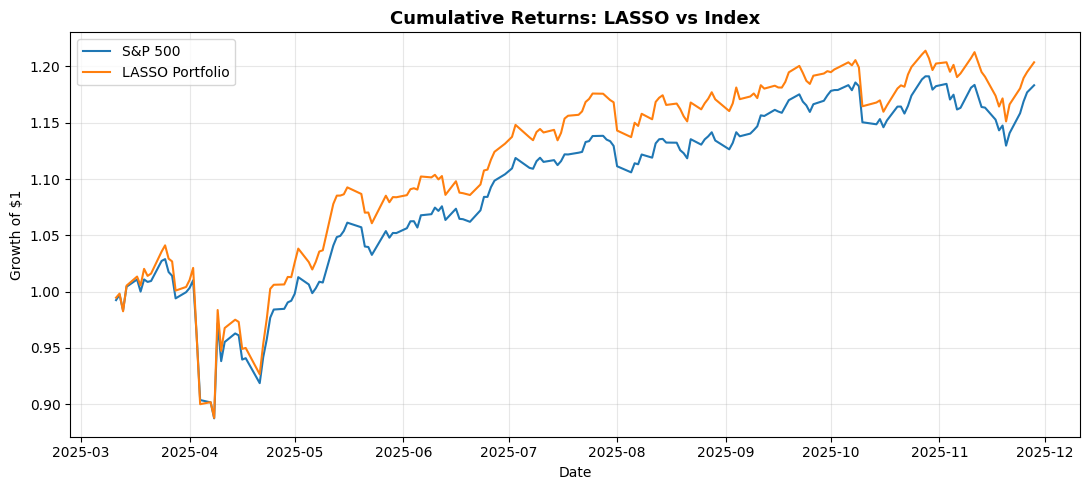

In [ ]:
# Final holdout performance for the chosen model
portfolio_hold = X_hold_raw.dot(best_weights).reindex(y_hold.index)
active_hold = (portfolio_hold - y_hold).dropna()

print('Holdout Tracking Error:', annualized_tracking_error(active_hold))
print('Holdout Information Ratio:', annualized_information_ratio(active_hold))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot((1 + y_hold).cumprod(), label='S&P 500')
ax.plot((1 + portfolio_hold).cumprod(), label='LASSO Portfolio')
ax.set_title('Cumulative Returns: LASSO vs Index', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

,weight
MSFT,0.111909
AAPL,0.108985
BRK-B,0.082957
APH,0.069888
AMZN,0.066560
AMP,0.061356
BLK,0.052623
GOOGL,0.037477
TEL,0.032854
NVDA,0.031534


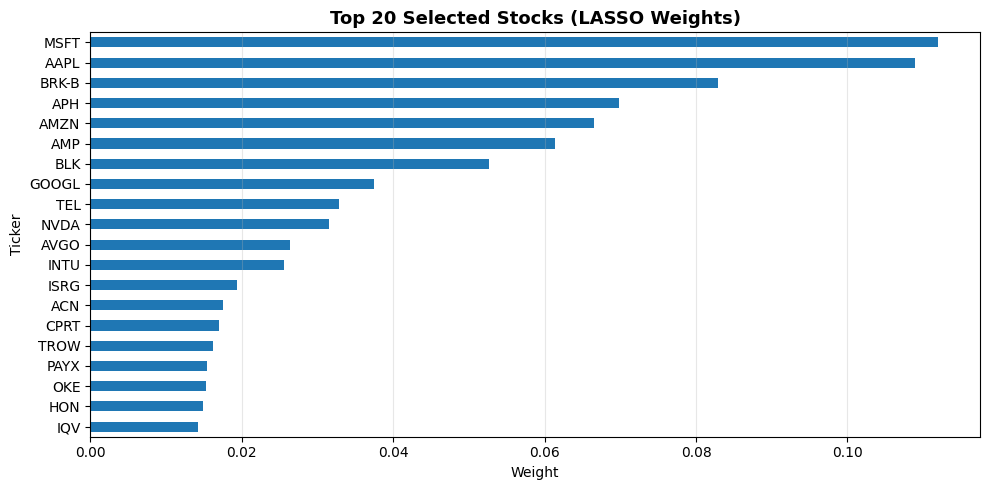

In [ ]:
# Compact weight summary for the selected portfolio
top_weights = best_weights[best_weights != 0].sort_values(ascending=False).head(20)
display(top_weights.to_frame('weight'))

fig, ax = plt.subplots(figsize=(10, 5))
top_weights.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 20 Selected Stocks (LASSO Weights)', fontsize=13, fontweight='bold')
ax.set_xlabel('Weight')
ax.set_ylabel('Ticker')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Wikipedia failed: HTTP Error 403: Forbidden


yfinance fallback:   0%|          | 0/561 [00:00<?, ?it/s]

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HBI"}}}


Final unknown rate: 0.5%


Fetching market caps:   0%|          | 0/561 [00:00<?, ?it/s]

ERROR:yfinance:$ATGE: possibly delisted; no price data found  (period=5d)
ERROR:yfinance:$DAY: possibly delisted; no price data found  (period=5d)


Sector weight mode: market-cap weighted


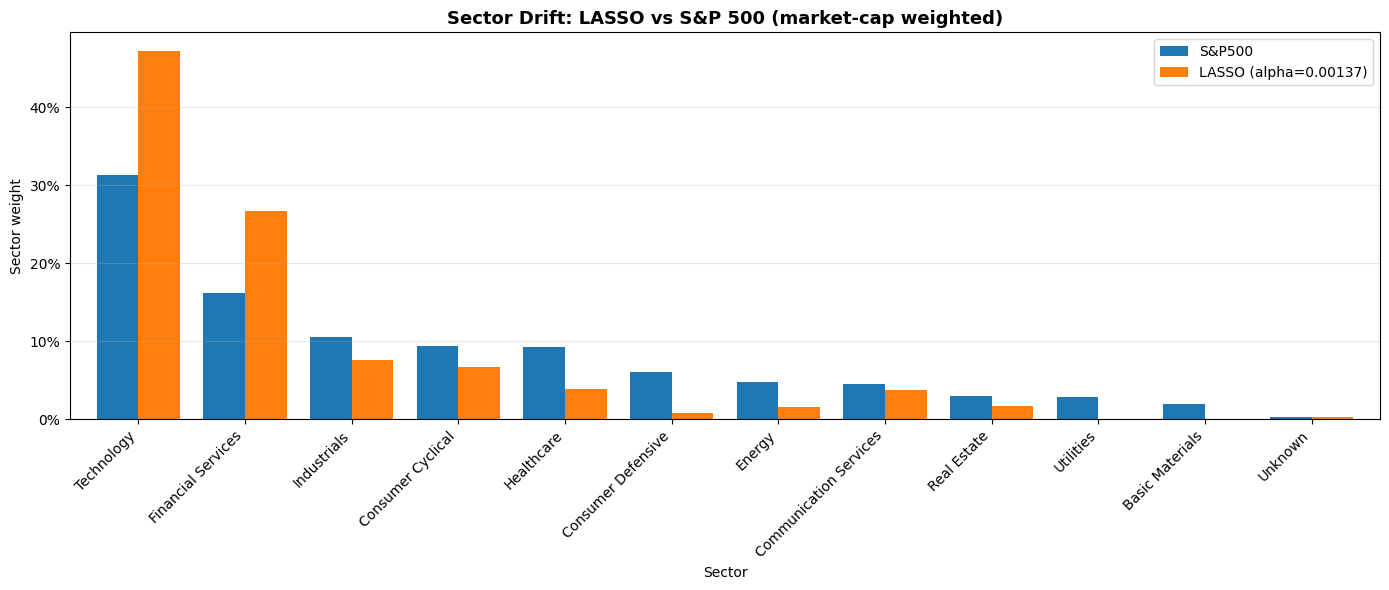

,S&P500,LASSO (alpha=0.00137)
sector,,
Technology,0.3135,0.4723
Financial Services,0.1618,0.2673
Industrials,0.1056,0.0759
Consumer Cyclical,0.0933,0.0666
Healthcare,0.0929,0.0386
Consumer Defensive,0.0600,0.0076
Energy,0.0481,0.0152
Communication Services,0.0450,0.0375
Real Estate,0.0289,0.0161


In [ ]:
# Sector drift plot for LASSO vs S&P 500
# Uses X_fit_s.columns as the universe

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from tqdm.auto import tqdm

SECTOR_CACHE    = Path("sp500_sector_cache.csv")
MARKETCAP_CACHE = Path("sp500_marketcap_cache.csv")

universe_tickers = list(X_fit_s.columns)

def get_sp500_sector_map(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached["ticker"])):
            unknown_rate = (cached["sector"] == "Unknown").mean()
            if unknown_rate < 0.10:
                print(f"Loaded sector map from cache (unknown rate: {unknown_rate:.1%})")
                return cached

    sector_map = {}
    try:
        tables = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
        wiki = tables[0]
        sym_col = [c for c in wiki.columns if "symbol" in str(c).lower() or "ticker" in str(c).lower()][0]
        sec_col = [c for c in wiki.columns if "gics sector" in str(c).lower() or "sector" in str(c).lower()][0]
        for _, row in wiki.iterrows():
            sym = str(row[sym_col]).strip().replace(".", "-")
            sector_map[sym] = str(row[sec_col]).strip()
        print(f"Wikipedia: mapped {len(sector_map)} tickers")
    except Exception as e:
        print(f"Wikipedia failed: {e}")

    still_unknown = [t for t in tickers if sector_map.get(t, "Unknown") == "Unknown"]
    if still_unknown:
        def fetch_yf(t):
            try:
                return t, yf.Ticker(t).get_info().get("sector") or "Unknown"
            except Exception:
                return t, "Unknown"

        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futs = {ex.submit(fetch_yf, t): t for t in still_unknown}
            for fut in tqdm(as_completed(futs), total=len(futs), desc="yfinance fallback"):
                t, s = fut.result()
                sector_map[t] = s

    df = pd.DataFrame([{"ticker": t, "sector": sector_map.get(t, "Unknown")} for t in tickers])
    print(f"Final unknown rate: {(df['sector'] == 'Unknown').mean():.1%}")

    try:
        df.to_csv(cache_path, index=False)
    except Exception as e:
        print("Warning: could not save cache:", e)

    return df

def get_market_caps(tickers, cache_path: Path, max_workers: int = 16):
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if set(tickers).issubset(set(cached["ticker"])):
            if cached["market_cap"].notna().mean() >= 0.5:
                print("Loaded market caps from cache")
                return cached

    def fetch_one(t):
        try:
            fi = getattr(yf.Ticker(t), "fast_info", None)
            mc = getattr(fi, "market_cap", np.nan) if fi is not None else np.nan
            if pd.isna(mc):
                mc = yf.Ticker(t).get_info().get("marketCap", np.nan)
        except Exception:
            mc = np.nan
        return {"ticker": t, "market_cap": mc}

    rows = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(fetch_one, t): t for t in tickers}
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Fetching market caps"):
            rows.append(fut.result())

    out = pd.DataFrame(rows)
    try:
        out.to_csv(cache_path, index=False)
    except Exception as e:
        print("Warning: could not save cache:", e)
    return out

# Build S&P 500 sector benchmark weights
sector_df = get_sp500_sector_map(universe_tickers, SECTOR_CACHE)
universe_info = sector_df.copy()

try:
    mcap = get_market_caps(universe_info["ticker"].tolist(), MARKETCAP_CACHE)
    universe_info = universe_info.merge(mcap, on="ticker", how="left")

    valid = universe_info["market_cap"].notna().sum()
    if valid >= max(30, int(0.3 * len(universe_info))):
        universe_info["market_cap"] = universe_info.groupby("sector")["market_cap"].transform(
            lambda s: s.fillna(s.median())
        ).fillna(universe_info["market_cap"].median())

        sector_weights_true = universe_info.groupby("sector")["market_cap"].sum()
        sector_weights_true = sector_weights_true / sector_weights_true.sum()
        sector_weight_mode = "market-cap weighted"
    else:
        raise ValueError("Too many missing market caps")
except Exception as e:
    print("Market cap failed, using equal-weight proxy:", e)
    sector_weights_true = universe_info["sector"].value_counts(normalize=True)
    sector_weight_mode = "equal-weight proxy"

print("Sector weight mode:", sector_weight_mode)

# Fit / use your LASSO model
# Change these if your notebook uses different names
if "best_alpha" not in globals():
    raise NameError("best_alpha is not defined. Fit/select your LASSO model first.")

if "lasso_model" in globals():
    model = lasso_model
elif "model" in globals():
    model = model
else:
    from sklearn.linear_model import Lasso
    model = Lasso(alpha=best_alpha, max_iter=10000)
    model.fit(X_fit_s, y_fit)

weights = pd.Series(model.coef_, index=X_fit_s.columns)

# Normalize like a portfolio
if np.sum(np.abs(weights.values)) != 0:
    weights = weights / np.sum(np.abs(weights.values))

# Aggregate LASSO weights by sector
lasso_df = pd.DataFrame({"ticker": weights.index, "weight": weights.values})
lasso_df = lasso_df.merge(universe_info[["ticker", "sector"]], on="ticker", how="left")
lasso_df["sector"] = lasso_df["sector"].fillna("Unknown")
sector_weights_lasso = lasso_df.groupby("sector")["weight"].sum()

# Compare
sector_compare = pd.DataFrame({
    "S&P500": sector_weights_true,
    f"LASSO (alpha={best_alpha:.5f})": sector_weights_lasso
}).fillna(0.0).sort_values("S&P500", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sector_compare.plot(kind="bar", ax=ax, width=0.78)

ax.set_ylabel("Sector weight")
ax.set_xlabel("Sector")
ax.set_title(f"Sector Drift: LASSO vs S&P 500 ({sector_weight_mode})",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

sector_compare.round(4)